## Start

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Image


In [2]:
cb_image = cv2.imread('CheckBoard.png',0)
print(cb_image)

[[224 224 224 ... 149 149 149]
 [224 224 224 ... 149 149 149]
 [224 224 224 ... 149 149 149]
 ...
 [ 21  21  21 ... 228 228 228]
 [ 21  21  21 ... 228 228 228]
 [ 21  21  21 ... 228 228 228]]


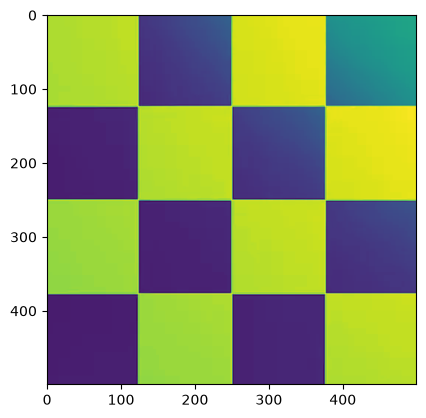

In [3]:
plt.imshow(cb_image)

In [4]:
print("image size:", cb_image.shape)

image size: (500, 500)


In [5]:
print("type of image:", type(cb_image))

type of image: <class 'numpy.ndarray'>


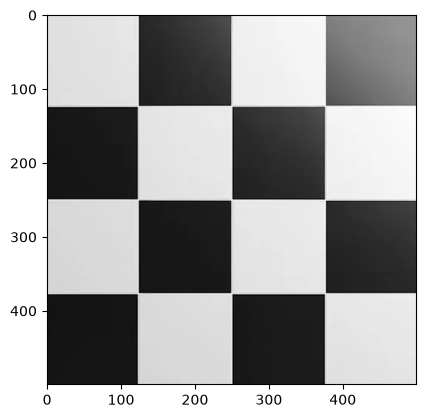

In [6]:
plt.imshow(cb_image, cmap='gray')

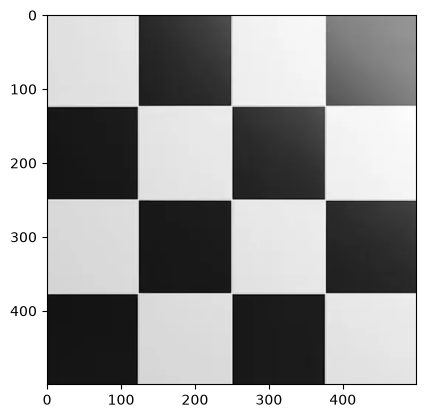

In [7]:
cb_image_rgb = cv2.cvtColor(cb_image, cv2.COLOR_BGR2RGB)
plt.imshow(cb_image_rgb)

Text(0.5, 1.0, 'RGB channel')

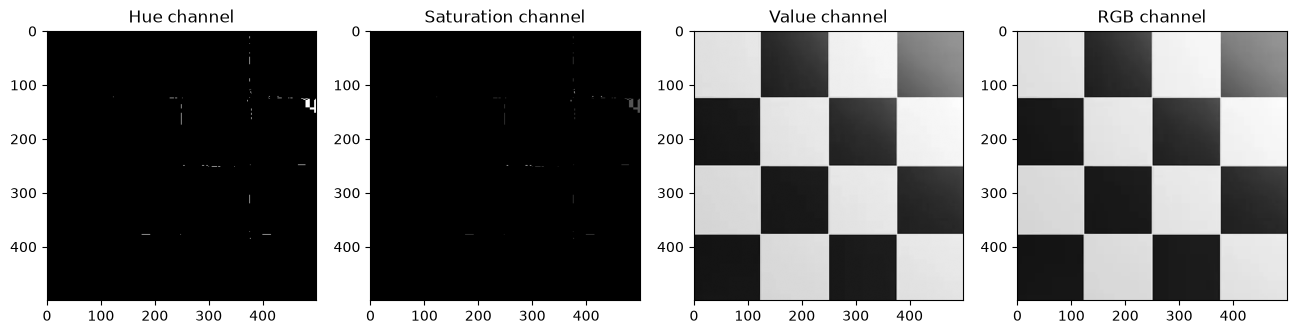

In [8]:
cb_image = cv2.imread("CheckBoard.png")
cb_image_hsv = cv2.cvtColor(cb_image, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(cb_image_hsv)

plt.figure(figsize=(16,4))
plt.subplot(1,4,1);plt.imshow(h, cmap='gray');plt.title('Hue channel')
plt.subplot(1,4,2);plt.imshow(s, cmap='gray');plt.title('Saturation channel')
plt.subplot(1,4,3);plt.imshow(v, cmap='gray');plt.title('Value channel')
plt.subplot(1,4,4);plt.imshow(cb_image_rgb);plt.title('RGB channel')


Text(0.5, 1.0, 'RGB channel')

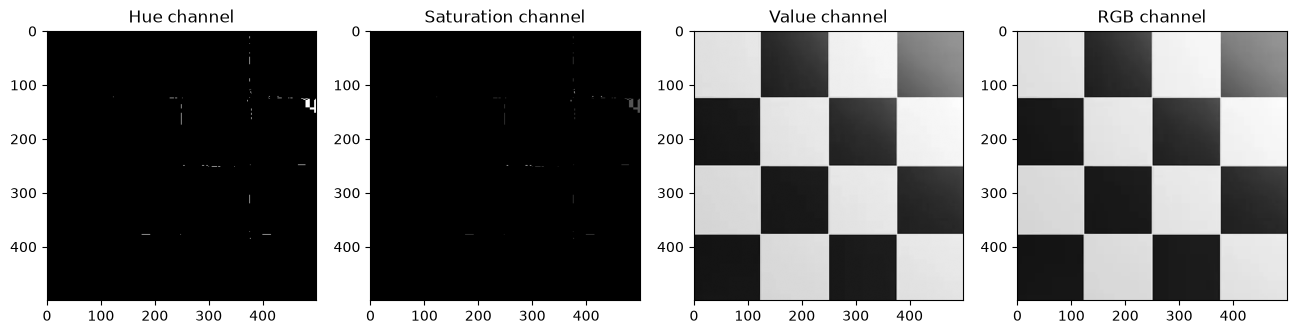

In [9]:
h_new = h + 10
image_hue_changed = cv2.merge((h_new, s, v))
image_hue_changed_rgb = cv2.cvtColor(image_hue_changed, cv2.COLOR_HSV2RGB)
plt.figure(figsize=(16,4))
plt.subplot(1,4,1);plt.imshow(h, cmap='gray');plt.title('Hue channel')
plt.subplot(1,4,2);plt.imshow(s, cmap='gray');plt.title('Saturation channel')
plt.subplot(1,4,3);plt.imshow(v, cmap='gray');plt.title('Value channel')
plt.subplot(1,4,4);plt.imshow(cb_image_rgb);plt.title('RGB channel')


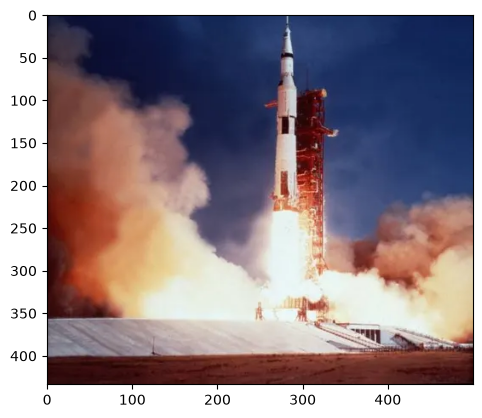

In [10]:
image = cv2.imread("Apollo.png", cv2.IMREAD_COLOR)
plt.imshow(image[..., ::-1])

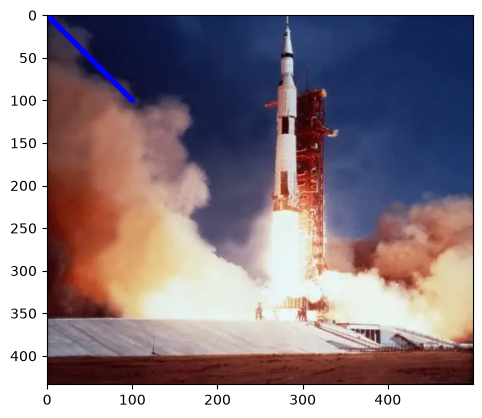

In [11]:
imgLine = image.copy()
cv2.line(imgLine, (0, 0), (100, 100), (255, 0, 0), thickness=5)
plt.imshow(imgLine[..., ::-1])

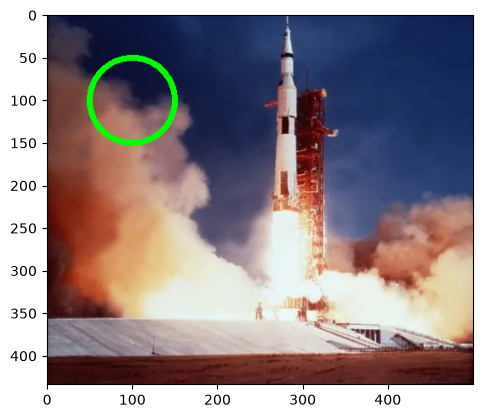

In [12]:
imgCircle = image.copy()
cv2.circle(imgCircle, (100, 100), 50, (0, 255, 0), thickness=5)
plt.imshow(imgCircle[..., ::-1])

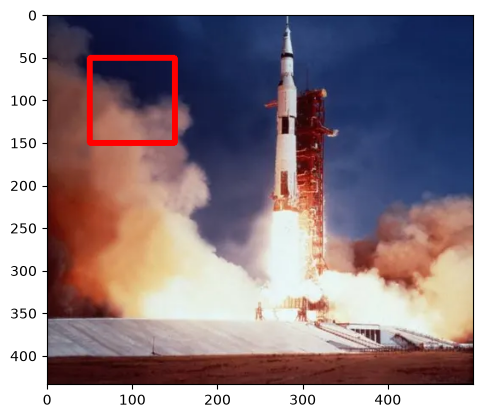

In [13]:
imgRectangle = image.copy()
cv2.rectangle(imgRectangle, (50, 50), (150, 150), (0, 0, 255), thickness=5)
plt.imshow(imgRectangle[..., ::-1])

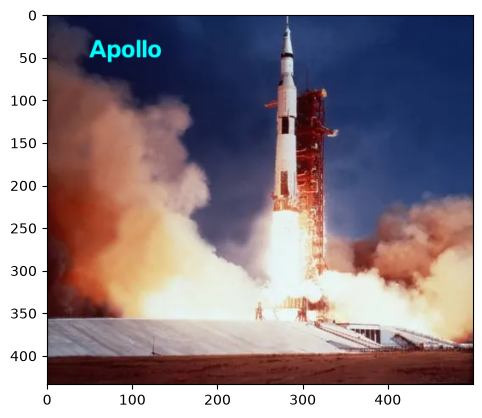

In [14]:
imgText = image.copy()
cv2.putText(imgText, "Apollo", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), thickness=2)
plt.imshow(imgText[..., ::-1])

Text(0.5, 1.0, 'Darker image')

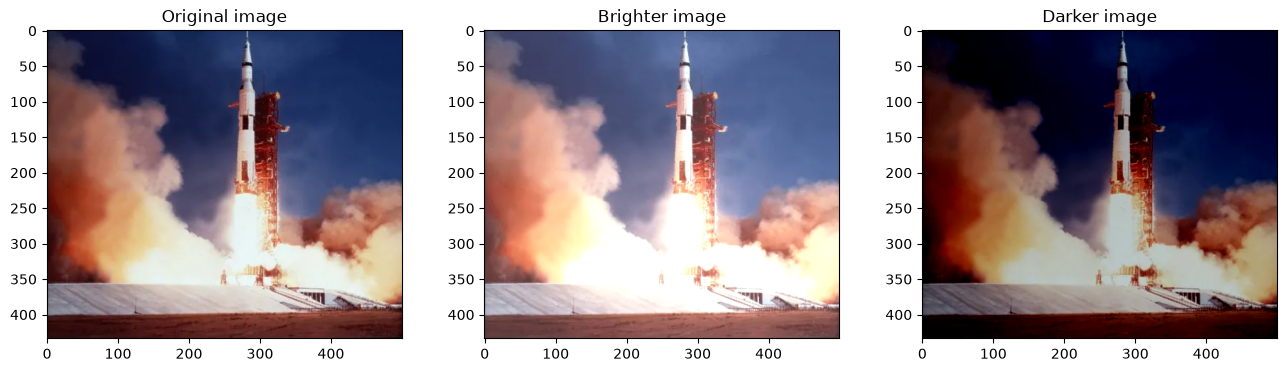

In [15]:
imgPrighter = cv2.add(image,np.ones(image.shape, image.dtype)*50)
imgDarker = cv2.subtract(image,np.ones(image.shape, image.dtype)*50)
plt.figure(figsize=(16,4))
plt.subplot(1,3,1);plt.imshow(image[..., ::-1]);plt.title('Original image')
plt.subplot(1,3,2);plt.imshow(imgPrighter[..., ::-1]);plt.title('Brighter image')
plt.subplot(1,3,3);plt.imshow(imgDarker[..., ::-1]);plt.title('Darker image')


In [16]:
im1 = cv2.imread("Form.png")
im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)
im2 = cv2.imread("Scan.png")
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)


Text(0.5, 1.0, 'Scan image')

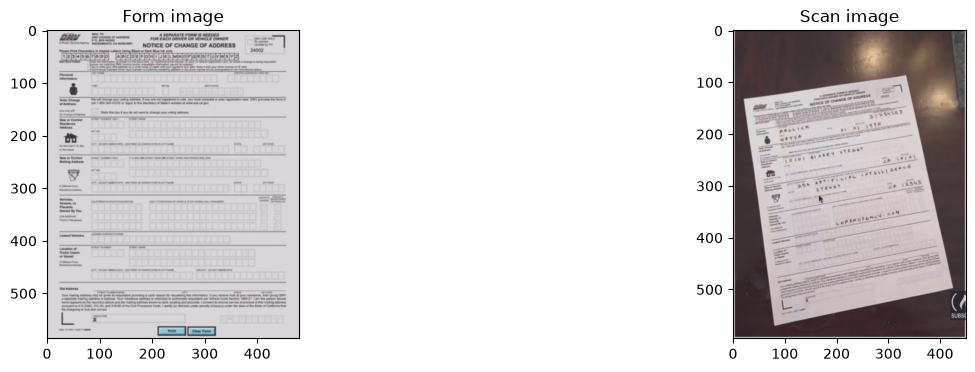

In [17]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1);plt.imshow(im1);plt.title('Form image')
plt.subplot(1,2,2);plt.imshow(im2);plt.title('Scan image')

In [20]:
im1_gray = cv2.cvtColor(im1, cv2.COLOR_RGB2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY)

MAX_FEATURES = 500
orb = cv2.ORB_create(MAX_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(im1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(im2_gray, None)
im1_with_keypoints = cv2.drawKeypoints(im1, keypoints1, outImage=np.array([], dtype=np.uint8), color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_with_keypoints = cv2.drawKeypoints(im2, keypoints2, outImage=np.array([], dtype=np.uint8), color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


Text(0.5, 1.0, 'Scan image')

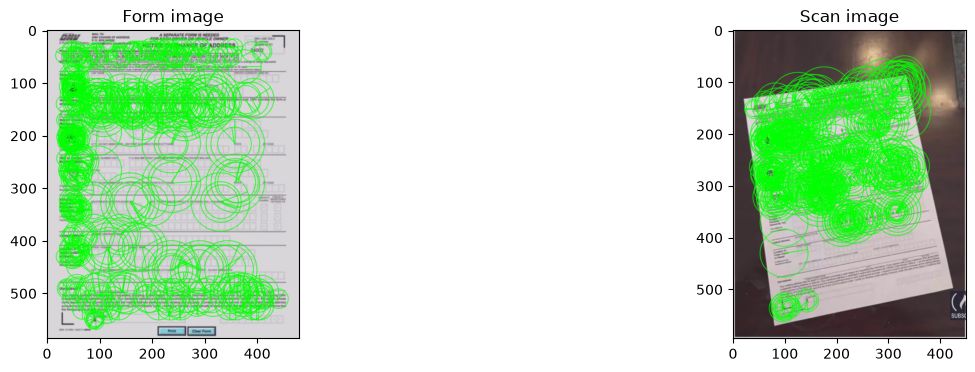

In [21]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1);plt.imshow(im1_with_keypoints);plt.title('Form image')
plt.subplot(1,2,2);plt.imshow(im2_with_keypoints);plt.title('Scan image')

In [23]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descriptors1, descriptors2, None)
matches = sorted(matches, key=lambda x: x.distance)
matches= matches[:int(len(matches)*0.1)]


Text(0.5, 1.0, 'Matches between Form and Scan images')

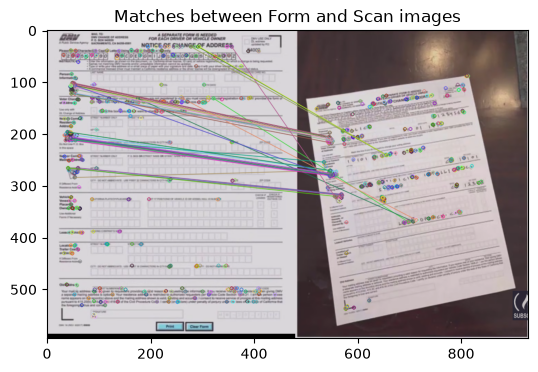

In [24]:
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)
plt.figure(figsize=(16,4))
plt.imshow(im_matches);plt.title('Matches between Form and Scan images')

In [27]:
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)
for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

Text(0.5, 1.0, 'Aligned Form image')

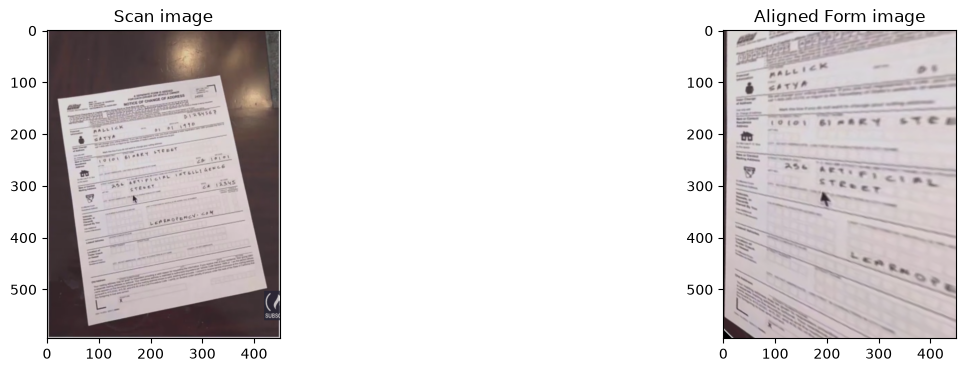

In [29]:
im2_aligned = cv2.warpPerspective(im2, h, (im2.shape[1], im2.shape[0]))
plt.figure(figsize=(16,4))
plt.subplot(1,2,1);plt.imshow(im2);plt.title('Scan image')
plt.subplot(1,2,2);plt.imshow(im2_aligned);plt.title('Aligned Form image')


## Object Tracking

In [50]:
from IPython.display import HTML
HTML("""
    <video width="1080" controls>
        <source src="Video.mp4" type="video/mp4">
    </video>
""")

In [33]:
import os
import urllib
from matplotlib.animation import FuncAnimation

video_path = "Video.mp4"
def draw_rectangle(frame,bbox):
    p1 = int(bbox[0]), int(bbox[1])
    p2 = int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3])
    cv2.rectangle(frame, p1, p2, (255,0,0), 2, 1)

def display_rectangle(frame,bbox):
    plt.figure(figsize=(8,6))
    framecopy = frame.copy()
    draw_rectangle(framecopy,bbox)
    plt.imshow(framecopy)

def draw_text(frame,text):
    cv2.putText(frame, text, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)



In [69]:
tracker_types = ['MIL', 'DaSiamRPN', 'Nano', 'Vit']


tracker_type = tracker_types[0]

if tracker_type == 'MIL':
    tracker = cv2.TrackerMIL_create()
elif tracker_type == 'DaSiamRPN':
    tracker = cv2.TrackerDaSiamRPN_create()
elif tracker_type == 'Nano':
    tracker = cv2.TrackerNano_create()
elif tracker_type == 'Vit':
    tracker = cv2.TrackerVit_create()


In [70]:
video = cv2.VideoCapture(video_path)
if not video.isOpened():
    print("Could not open video")
    exit()

ok, frame = video.read()

if not ok:
    print("Could not read first frame")
    exit()


width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = video.get(cv2.CAP_PROP_FPS)


video_output_name = "race" + tracker_type + ".mp4"

video_output = cv2.VideoWriter(
    video_output_name,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)


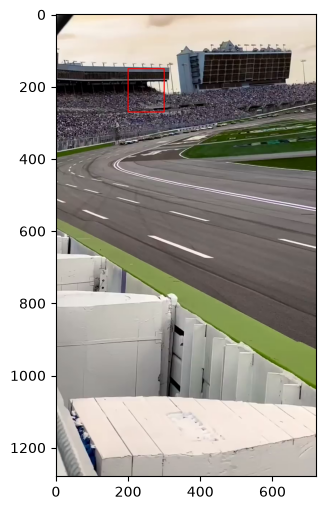

In [71]:
bbox = (200, 150, 100, 120)

display_rectangle(frame, bbox)


In [72]:
print("OpenCV:", cv2.__version__)
print("Tracker:", type(tracker))
print("Frame shape:", frame.shape)
print("Frame dtype:", frame.dtype)
print("BBox:", bbox)

OpenCV: 5.0.0
Tracker: <class 'cv2.TrackerMIL'>
Frame shape: (1280, 720, 3)
Frame dtype: uint8
BBox: (200, 150, 100, 120)


In [73]:
ok = tracker.init(frame, bbox)


In [74]:
while True:

    ok, frame = video.read()

    if not ok:
        break

    timer = cv2.getTickCount()

    ok, bbox = tracker.update(frame)

    fps_tracker = cv2.getTickFrequency() / (
        cv2.getTickCount() - timer
    )

    if ok:
        draw_rectangle(frame, bbox)
    else:
        draw_text(frame, "Tracking failure")

    draw_text(frame, tracker_type + " Tracker")
    draw_text(frame, f"FPS: {fps_tracker:.2f}")

    video_output.write(frame)


video.release()
video_output.release()